In [1]:
import cv2
import os
import pandas as pd
import torch
from torch import nn as nn
from torch import optim as optim
from torch.utils.data import Dataset, DataLoader, random_split
from torchvision.io import decode_image
from torchvision.transforms import v2
from torch.utils.tensorboard import SummaryWriter
from PIL import Image
from matplotlib import pyplot as plt
from FHFData import Kantec2509Dataset
from transformers import get_cosine_schedule_with_warmup

In [2]:
device = "cuda" if torch.cuda.is_available() else "cpu"
device

'cuda'

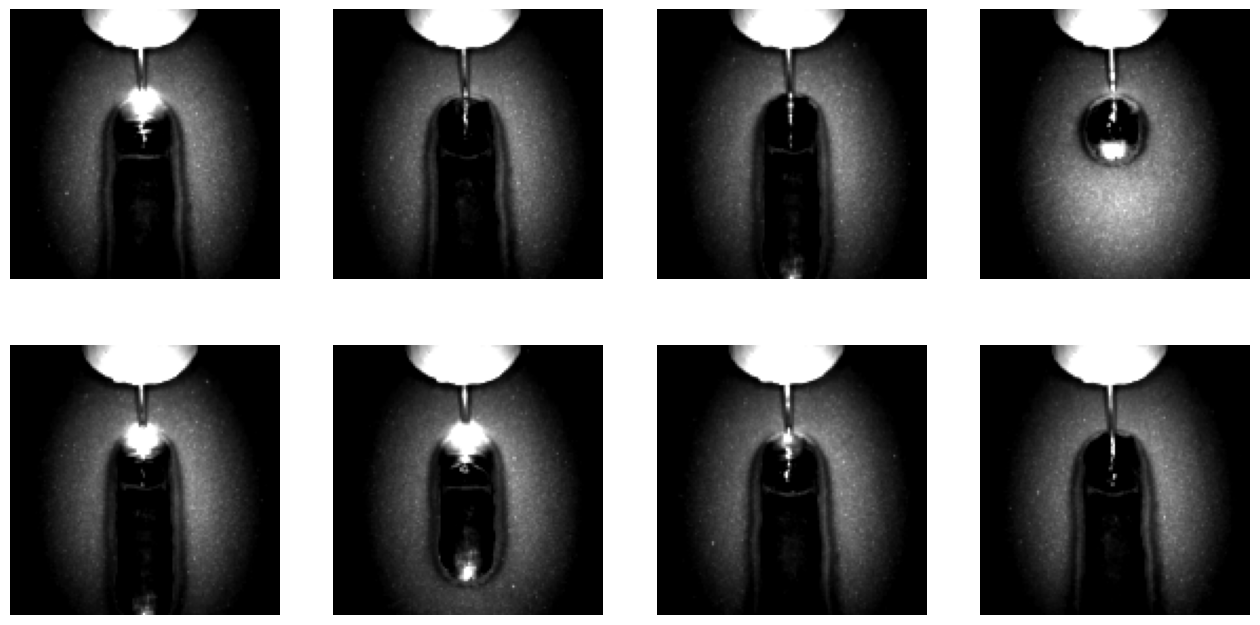

In [3]:
BATCH_SIZE = 128

transform = v2.Compose([
    v2.Resize((128, 128)),
    v2.ColorJitter(contrast=(2.0, 2.0)),
    v2.ToImage(),
    v2.ToDtype(torch.float32, scale=True)
])

dataset = Kantec2509Dataset(transform=transform)

train_size = int(0.8 * len(dataset))
val_size = int(0.1 * len(dataset))
test_size = len(dataset) - train_size - val_size

train_dataset, val_dataset, test_dataset = random_split(dataset, [train_size, val_size, test_size])

train_dataloader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_dataloader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)
test_dataloader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

batch = next(iter(train_dataloader))
images = batch

fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes = axes.flatten()
for i, img in enumerate(images[:8]):
    axes[i].imshow(img.permute(1, 2, 0), cmap="gray")
    axes[i].axis("off")

In [ ]:
class ResidualBlock(nn.Module):
    def __init__(self, in_channels, out_channels, stride=1, reduction=16):
        super(ResidualBlock, self).__init__()

        # conv1
        self.conv1 = nn.Conv2d(in_channels, out_channels, kernel_size=3, stride=stride, padding=1, bias=False)
        self.bn1 = nn.BatchNorm2d(out_channels)
        self.relu = nn.ReLU(inplace=True)

        # conv2
        self.conv2 = nn.Conv2d(out_channels, out_channels, kernel_size=3, stride=stride, padding=1, bias=False)
        self.bn2 = nn.BatchNorm2d(out_channels)

        # Squeeze-and-Excitation (SE) Block
        self.avg_pool = nn.AdaptiveAvgPool2d(1)
        self.fc1 = nn.Linear(out_channels, out_channels // reduction, bias=False)
        self.fc2 = nn.Linear(out_channels // reduction, out_channels, bias=False)
        self.sigmoid = nn.Sigmoid()

        self.skip_connection = nn.Sequential()
        if stride != 1 or in_channels != out_channels:
            self.skip_connection = nn.Sequential(
                nn.Conv2d(in_channels, out_channels, kernel_size=1, stride=stride, bias=False),
                nn.BatchNorm2d(out_channels)
            )

    def forward(self, x):
        identity = self.skip_connection(x)

        # Conv1 block
        out = self.conv1(x)
        out = self.bn1(out)
        out = self.relu(out)

        # Conv2 block
        out = self.conv2(out)
        out = self.bn2(out)

        # Squeeze-and-Excitation path
        se_branch = self.avg_pool(out) # Global pooling
        se_branch = se_branch.view(se_branch.size(0), -1)
        se_branch = self.fc1(se_branch)
        se_branch = self.relu(se_branch)
        se_branch = self.fc2(se_branch)
        se_branch = self.sigmoid(se_branch)
        se_branch = se_branch.view(se_branch.size(0), se_branch.size(1), 1, 1)

        out = out * se_branch.expand(out)

        out = out + identity

        return out

In [ ]:
class ConvBlock(nn.Module):
    def __init__(self, in_channels, out_channels, kernel_size=3, stride=1, padding=1, bias=False, activate=True):
        super(ConvBlock, self).__init__()
        self.conv = nn.Conv2d(in_channels, out_channels, kernel_size=kernel_size, stride=stride, padding=padding, bias=bias)
        self.bn = nn.BatchNorm2d(out_channels)
        self.relu = nn.ReLU(inplace=True)
        self.activate = activate

    def forward(self, x):
        x = self.conv(x)
        x = self.bn(x)
        if self.activate:
            x = self.relu()
        return x

In [ ]:
class TransposeConvBlock(nn.Module):
    def __init__(self, in_channels, out_channels, kernel_size=2, stride=2, padding=0, output_padding=0, bias=False, activate=True):
        super(TransposeConvBlock, self).__init__()
        # kernel_size=2, stride=2, padding=0 for upsampling by factor of 2
        self.transconv = nn.ConvTranspose2d(in_channels, out_channels, kernel_size=kernel_size, stride=stride, padding=padding, output_padding=output_padding, bias=bias)
        self.bn = nn.BatchNorm2d(out_channels)
        self.relu = nn.ReLU(inplace=True)
        self.activate = activate

    def forward(self, x):
        x = self.transconv(x)
        x = self.bn(x)
        if self.activate:
            x = self.relu()
        return x

In [ ]:
class VectorQuantization(nn.Module):
    def __init__(self, num_embeddings, embedding_dim, beta = 0.25):
        super(VectorQuantization, self).__init__()
        self.num_embeddings = num_embeddings
        self.embedding_dim = embedding_dim
        self.beta = beta

        self.embedding = nn.Embedding(self.num_embeddings, self.embedding_dim)
        nn.init.uniform_(self.embedding.weight.data, -1.0 / self.num_embeddings, 1.0 / self.num_embeddings)

    def forward(self, z):
        input_shape = z.shape()
        flat_z = z.permute(0, 2, 3, 1).contiguous() if z.dim() == 4 else z
        flat_z = flat_z.view(-1, self.embedding_dim) # (N*H*W, embedding_dim)
        return x, torch.tensor(0.)

In [ ]:
class VQVCAE(nn.Module):
    def __init__(self):
        super(VQVCAE, self).__init__()

        self.conv1 = nn.Conv2d(1, 64, kernel_size=4, stride=2, padding=1)
        self.conv2 = nn.Conv2d(64, 128, kernel_size=4, stride=2, padding=1)
        self.conv3 = nn.Conv2d(128, 256, kernel_size=4, stride=2, padding=1)
        self.resblock1 = nn.Sequential(ResidualBlock(256, 256), ResidualBlock(256, 256))
        self.conv4 = nn.Conv2d(256, 512, kernel_size=4, stride=2, padding=1)
        self.conv5 = nn.Conv2d(512, 512, kernel_size=3, stride=1, padding=1)
        self.resblock2 = nn.Sequential(ResidualBlock(512), ResidualBlock(512))
        self.conv6 = nn.Conv2d(512, 256, kernel_size=1)
        self.vector_quantization1 = VectorQuantization()
        self.conv_skip = nn.Conv2d(256, 256, kernel_size=3, stride=1, padding=1)
        self.conv7 = nn.Conv2d(256, 512, kernel_size=3, padding=1)
        self.resblock3 = nn.Sequential(ResidualBlock(512), ResidualBlock(512))
        self.transconv1 = nn.ConvTranspose2d(512, 256, kernel_size=4, stride=2, padding=1)
        
        self.conv8 = nn.Conv2d(256 + 256, 256, kernel_size=3, padding=1)
        self.conv9 = nn.Conv2d(256, 128, kernel_size=3, padding=1)
        self.vector_quantization2 = VectorQuantization()
        
        self.conv10 = nn.Conv2d(128, 64, kernel_size=3, padding=1)
        self.resblock4 = nn.Sequential(ResidualBlock(64), ResidualBlock(64))
        self.transconv2 = nn.ConvTranspose2d(64, 1, kernel_size=4, stride=2, padding=1)

    def forward(self, x):
        x = self.conv1(x) # 128 -> 64
        x = self.conv2(x) # 64 -> 32
        x = self.conv3(x) # 32 -> 16
        x = self.resblock1(x) # 16 -> 16
        x1 = x # 16

        x = self.conv4(x) # 16 -> 8
        x = self.conv5(x) # 8 -> 8
        x = self.resblock2(x) # 8 -> 8
        x2 = x # 8

        x = self.conv6(x) # 8 -> 8
        quantized_x1, quant_loss = self.vector_quantization1(x) # 8 -> 8
        x3 = self.conv_skip(quantized_x1) # 8 -> 8

        x = self.conv7(quantized_x) # 8 -> 8
        x = self.resblock3(x) # 8 -> 8
        x = self.transconv1(x) # 8 -> 16

        x = torch.cat([x, x1], dim=1) # [16, 16] -> 32x16
        x = self.conv8(x) # 32x16 -> 32x16
        x = self.conv9(x) # 32x16 -> 32x16

        quantized_x2, quant_loss2 = self.vector_quantization2(x) # 32x16 -> 32x16
        x = torch.cat([quantized_x2, x3], dim=1) # [32x16, 8] -> ERROR
        x = self.conv10(x) # 
        x = self.resblock4(x)
        x = self.transconv2(x)

        return x, quant_loss + quant_loss2

In [ ]:
_model_cpu = VQVCAE()
_model = _model_cpu.to(device)

_input_tensor_cpu = torch.randn(128, 1, 128, 128)
_input_tensor = _input_tensor_cpu.to(device)
_output, _loss = _model(_input_tensor)
print(_output.shape) # should be (128, 1, 128, 128)

In [ ]:
INITIAL_LR = 1e-4
NUM_EPOCHS = 500
WARMUP_EPOCHS = 50
WARMUP_STEPS = len(dataset) * WARMUP_EPOCHS
TRAIN_STEPS = len(dataset) * NUM_EPOCHS

model = VQVCAE()
model.to(device)

optimizer = optim.Adam(model.parameters(), lr=INITIAL_LR)
scheduler = get_cosine_schedule_with_warmup(
    optimizer,
    num_warmup_steps=WARMUP_STEPS,
    num_training_steps=TRAIN_STEPS
)

In [ ]:
writer = SummaryWriter()

for epoch in range(NUM_EPOCHS):
    # Training phase
    model.train()

    for batch_idx, images_cpu in enumerate(train_dataloader)
        images = images_cpu.to(device)

    # Validation phase
    model.eval()

    # Test phase